# Лабораторная работа №4

Егорова Варвара Александровна, 408575, P3323

****

**Цель работы:** изучение принципов функционирования и приобретение навыков программной реализации клеточных автоматов как дискретных вычислительных моделей.

**Порядок выполнения**
1. Разработать программную реализацию элементарного одномерного клеточного автомата, например, Правило 30, Правило 90, Правило 110 и др.
Построить визуализацию нескольких итераций эволюции автомата при различных начальных условиях.
2. Реализовать модель двумерного клеточного автомата "Жизнь".

Классические правила игры "Жизнь":
- в пустой (мёртвой) клетке, с которой соседствуют три живые клетки, зарождается жизнь;
- если у живой клетки есть две или три живые соседки, клетка продолжает жить;
- в противном случае (если живых соседей меньше двух или больше трёх) клетка умирает («от одиночества» или «от перенаселённости»).

3. Провести серию экспериментов (не менее 5) со случайным начальным заполнением поля.
Для каждого значения плотности заполнения (вероятности p, что клетка жива) провести не менее 10 запусков и подсчитать . Стабильной фазой считать момент, когда в течение N (например, 10) поколений общее количество живых клеток не меняется (или меняется циклически между двумя значениями).
4. По полученным данным построить график зависимости среднего времени стабилизации от начальной плотности заполнения поля автомата.
5. Классифицировать возникающие в процессе моделирования фигуры (паттерны).
Подсчитать количество изолированных комбинаций клеток (объектов) и сопоставить их с известными образцами.

Некоторые виды фигур в игре "Жизнь":
- Устойчивые фигуры остаются неизменными в следующих поколениях.
- Периодические фигуры - их состояние повторяется через некоторое число поколений.
- Движущиеся фигуры - состояние повторяется, при этом изменяется положение в пространстве, например, "глайдер" (планер).
- Ружья - фигуры с повторяющимися состояниями, которые дополнительно создают двигающиеся фигуры.
- Паровозы - двигающиеся фигуры, которые оставляют за собой следы в виде устойчивых или периодических фигур.
- Пожиратели - устойчивые фигуры, которые могут пережить столкновения с некоторыми двигающимися фигурами.
- Отражатели - устойчивые или периодические фигуры, способные при столкновении с ними движущихся фигур поменять их направление.
- Размножители - конфигурации, количество живых клеток в которых растёт как квадрат количества шагов.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque, Counter
from IPython.display import display

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "binary"
np.random.seed(42)

In [ ]:
def rule_to_outputs(rule: int) -> np.ndarray:
    """
    Преобразует номер правила (например, 30, 90, 110)
    в массив из 8 выходных значений для троек соседей.
    """
    return np.array([(rule >> i) & 1 for i in range(8)], dtype=np.uint8)


def step_1d(state: np.ndarray, rule: int) -> np.ndarray:
    """
    Выполняет один шаг эволюции одномерного клеточного автомата.
    Границы считаем мёртвыми (нулевыми), а не циклическими.
    """
    outputs = rule_to_outputs(rule)

    padded = np.pad(state, (1, 1), mode="constant", constant_values=0)
    left = padded[:-2]
    center = padded[1:-1]
    right = padded[2:]

    # Кодируем тройку (left, center, right) как число от 0 до 7
    idx = (left << 2) | (center << 1) | right
    return outputs[idx]


def run_1d(initial_state: np.ndarray, rule: int, steps: int) -> np.ndarray:
    """
    Запускает автомат на несколько шагов и сохраняет всю историю.
    """
    state = initial_state.copy().astype(np.uint8)
    history = [state.copy()]

    for _ in range(steps - 1):
        state = step_1d(state, rule)
        history.append(state.copy())

    return np.array(history)


def single_cell_initial(width: int) -> np.ndarray:
    """
    Начальное условие: одна живая клетка в центре.
    """
    state = np.zeros(width, dtype=np.uint8)
    state[width // 2] = 1
    return state


def random_initial(width: int, p: float = 0.5, seed: int = None) -> np.ndarray:
    """
    Случайное начальное условие: клетка жива с вероятностью p.
    """
    rng = np.random.default_rng(seed)
    return (rng.random(width) < p).astype(np.uint8)


def plot_1d_history(history: np.ndarray, title: str):
    """
    Визуализирует историю 1D автомата:
    строки — поколения, столбцы — клетки.
    """
    plt.figure(figsize=(10, 6))
    plt.imshow(history, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.xlabel("Положение клетки")
    plt.ylabel("Номер поколения")
    plt.show()

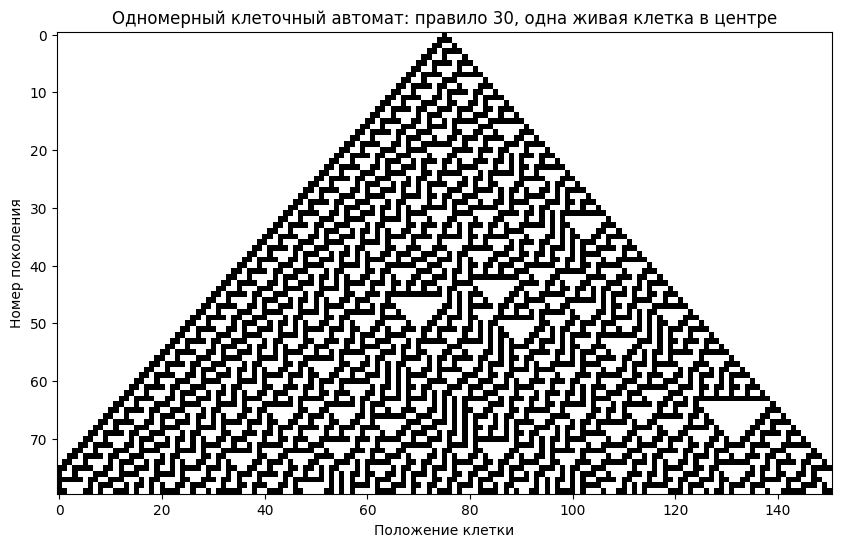

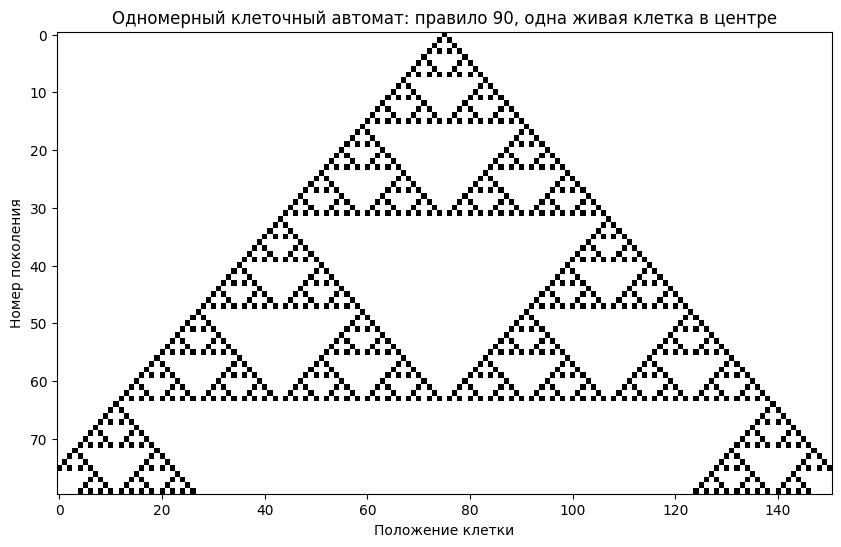

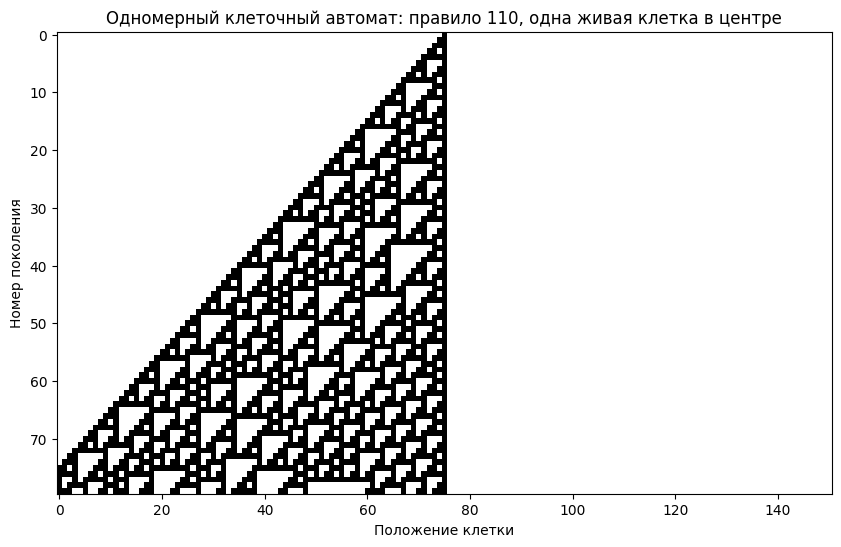

In [ ]:
width = 151
steps = 80

for rule in [30, 90, 110]:
    init = single_cell_initial(width)
    history = run_1d(init, rule, steps)
    plot_1d_history(history, f"Одномерный клеточный автомат: правило {rule}, одна живая клетка в центре")

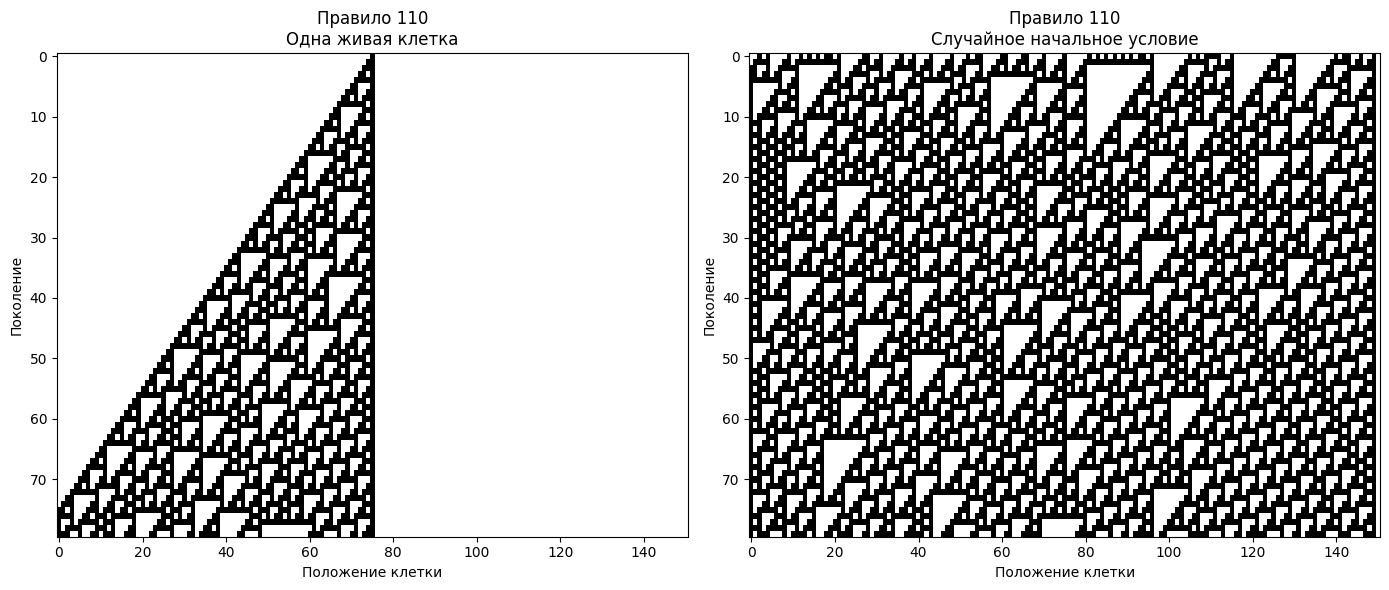

In [ ]:
rule = 110
width = 151
steps = 80

init_center = single_cell_initial(width)
init_random = random_initial(width, p=0.35, seed=1)

hist_center = run_1d(init_center, rule, steps)
hist_random = run_1d(init_random, rule, steps)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(hist_center, interpolation="nearest", aspect="auto")
axes[0].set_title("Правило 110\nОдна живая клетка")
axes[0].set_xlabel("Положение клетки")
axes[0].set_ylabel("Поколение")

axes[1].imshow(hist_random, interpolation="nearest", aspect="auto")
axes[1].set_title("Правило 110\nСлучайное начальное условие")
axes[1].set_xlabel("Положение клетки")
axes[1].set_ylabel("Поколение")

plt.tight_layout()
plt.show()

In [ ]:
def random_board(rows: int, cols: int, p: float = 0.3, seed: int = None) -> np.ndarray:
    """
    Генерирует случайное поле: клетка жива с вероятностью p.
    """
    rng = np.random.default_rng(seed)
    return (rng.random((rows, cols)) < p).astype(np.uint8)


def life_neighbors(board: np.ndarray) -> np.ndarray:
    """
    Считает количество живых соседей для каждой клетки.
    Границы считаем мёртвыми.
    """
    padded = np.pad(board, 1, mode="constant", constant_values=0)

    neighbors = (
        padded[:-2, :-2] + padded[:-2, 1:-1] + padded[:-2, 2:] +
        padded[1:-1, :-2]                      + padded[1:-1, 2:] +
        padded[2:, :-2]  + padded[2:, 1:-1]  + padded[2:, 2:]
    )
    return neighbors


def step_life(board: np.ndarray) -> np.ndarray:
    """
    Один шаг игры 'Жизнь' по классическим правилам Конвея.
    """
    n = life_neighbors(board)

    next_board = (
        ((board == 1) & ((n == 2) | (n == 3))) |
        ((board == 0) & (n == 3))
    )

    return next_board.astype(np.uint8)


def run_life(initial_board: np.ndarray, steps: int):
    """
    Запускает игру 'Жизнь' на несколько поколений и сохраняет историю.
    """
    board = initial_board.copy().astype(np.uint8)
    history = [board.copy()]

    for _ in range(steps):
        board = step_life(board)
        history.append(board.copy())

    return history


def plot_snapshots(history, generations):
    """
    Показывает несколько поколений на одном рисунке.
    """
    n = len(generations)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, gen in zip(axes, generations):
        ax.imshow(history[gen], interpolation="nearest")
        ax.set_title(f"Поколение {gen}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

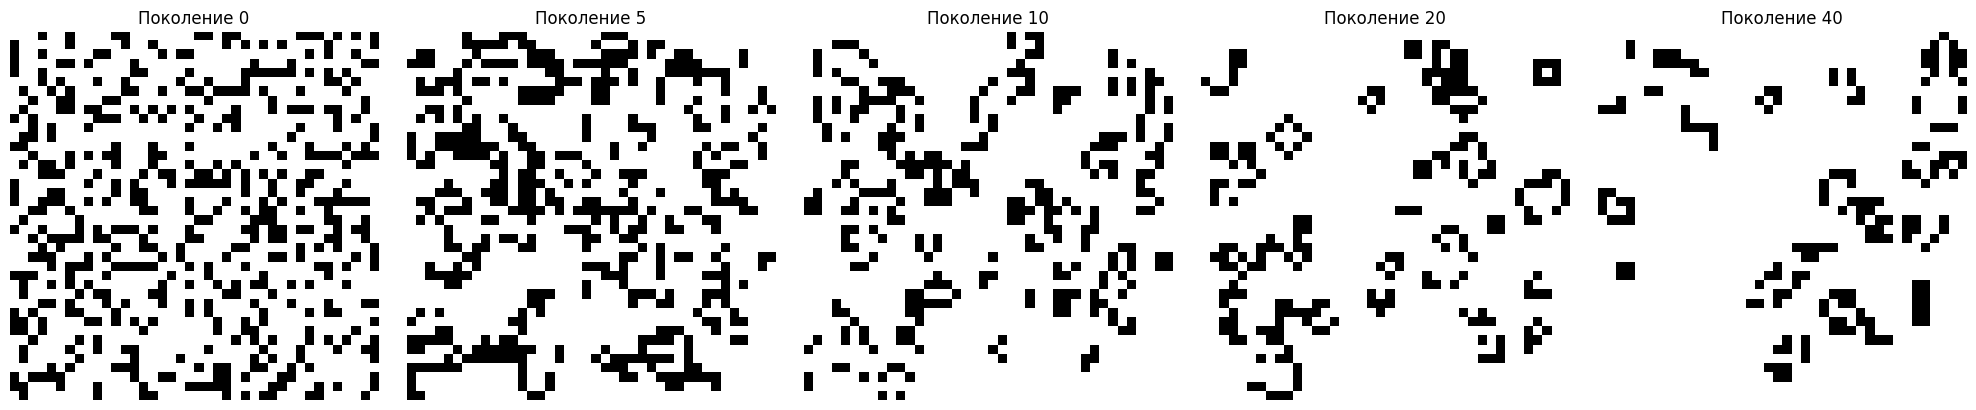

In [ ]:
board_demo = random_board(40, 40, p=0.3, seed=7)
history_demo = run_life(board_demo, steps=40)

plot_snapshots(history_demo, generations=[0, 5, 10, 20, 40])

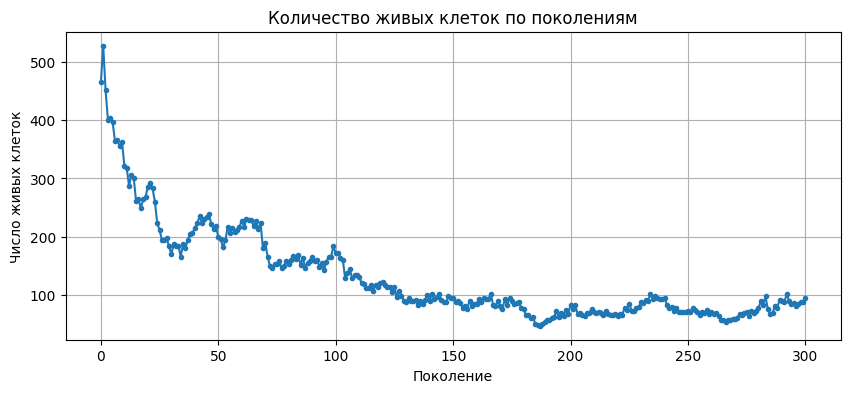

Время стабилизации: не достигнуто за max_steps


In [ ]:
def is_constant_or_two_cycle(values) -> bool:
    """
    Проверяет, является ли последовательность:
    - постоянной, или
    - чередующейся между двумя значениями (период 2)
    """
    values = list(values)

    # Случай полной стабилизации
    if len(set(values)) == 1:
        return True

    # Для периода 2 допускаем только два разных значения
    if len(set(values)) > 2:
        return False

    a = values[0]
    b = values[1]

    # Проверяем шаблон a, b, a, b, ...
    return all(values[i] == (a if i % 2 == 0 else b) for i in range(len(values)))


def simulate_until_stable(initial_board: np.ndarray, max_steps: int = 300, window: int = 10):
    """
    Моделирует игру 'Жизнь' до стабилизации или до max_steps.

    Стабилизацией считаем момент, когда за последние window поколений:
    - число живых клеток постоянно, или
    - меняется циклически между двумя значениями.
    """
    board = initial_board.copy().astype(np.uint8)
    history = [board.copy()]
    counts = [int(board.sum())]

    for step in range(1, max_steps + 1):
        board = step_life(board)
        history.append(board.copy())
        counts.append(int(board.sum()))

        if len(counts) >= window:
            if is_constant_or_two_cycle(counts[-window:]):
                return step, board, counts, history

    return None, board, counts, history


# Один пример запуска
board_example = random_board(40, 40, p=0.3, seed=15)
t_stable, final_board_example, counts_example, history_example = simulate_until_stable(
    board_example,
    max_steps=300,
    window=10
)

plt.figure(figsize=(10, 4))
plt.plot(counts_example, marker="o", markersize=3)
plt.title("Количество живых клеток по поколениям")
plt.xlabel("Поколение")
plt.ylabel("Число живых клеток")
plt.grid(True)
plt.show()

print("Время стабилизации:", t_stable if t_stable is not None else "не достигнуто за max_steps")

In [ ]:
p_values = np.linspace(0.1, 0.9, 9)   # 9 значений плотности
runs_per_p = 10                       # не менее 10 запусков для каждого p
rows, cols = 40, 40
max_steps = 300
window = 10

rng = np.random.default_rng(123)

results = []
sample_final_board = None  # одно поле потом используем для классификации фигур

for p in p_values:
    times = []
    stabilized_runs = 0

    for run_idx in range(runs_per_p):
        board = (rng.random((rows, cols)) < p).astype(np.uint8)

        t_stable, final_board, counts, history = simulate_until_stable(
            board,
            max_steps=max_steps,
            window=window
        )

        if t_stable is not None:
            times.append(float(t_stable))
            stabilized_runs += 1

            # Сохраним один пример стабилизировавшегося поля для анализа паттернов
            if sample_final_board is None:
                sample_final_board = final_board.copy()
        else:
            times.append(np.nan)

    times_arr = np.array(times, dtype=float)

    avg_time = np.nanmean(times_arr) if np.isfinite(times_arr).any() else np.nan
    std_time = np.nanstd(times_arr) if np.isfinite(times_arr).any() else np.nan

    results.append({
        "p": p,
        "avg_stabilization_time": avg_time,
        "std_stabilization_time": std_time,
        "stabilized_runs": stabilized_runs,
        "total_runs": runs_per_p
    })

results_df = pd.DataFrame(results)
display(results_df)

,p,avg_stabilization_time,std_stabilization_time,stabilized_runs,total_runs
0,0.1,97.750000,91.210951,8,10
1,0.2,195.800000,65.471826,5,10
2,0.3,167.000000,70.061877,3,10
3,0.4,183.000000,39.805778,4,10
4,0.5,242.000000,48.595267,4,10
5,0.6,193.833333,57.897659,6,10
6,0.7,89.285714,47.577649,7,10
7,0.8,42.800000,77.856021,10,10
8,0.9,11.700000,0.458258,10,10


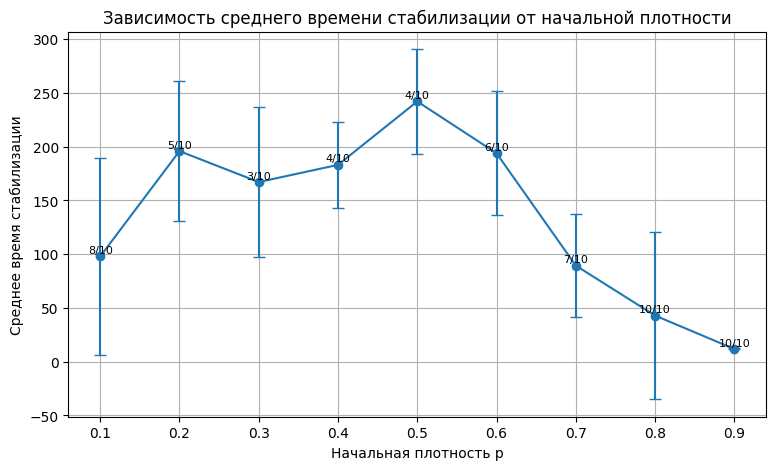

In [ ]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    results_df["p"],
    results_df["avg_stabilization_time"],
    yerr=results_df["std_stabilization_time"],
    marker="o",
    capsize=4
)

plt.title("Зависимость среднего времени стабилизации от начальной плотности")
plt.xlabel("Начальная плотность p")
plt.ylabel("Среднее время стабилизации")
plt.grid(True)

for _, row in results_df.iterrows():
    if pd.notna(row["avg_stabilization_time"]):
        plt.text(
            row["p"],
            row["avg_stabilization_time"] + 3,
            f'{int(row["stabilized_runs"])}/{int(row["total_runs"])}',
            ha="center",
            fontsize=8
        )

plt.show()

In [ ]:
def trim_pattern(pattern: np.ndarray) -> np.ndarray:
    """
    Убирает пустые строки и столбцы вокруг фигуры.
    """
    rows = np.where(pattern.sum(axis=1) > 0)[0]
    cols = np.where(pattern.sum(axis=0) > 0)[0]

    if len(rows) == 0 or len(cols) == 0:
        return np.zeros((0, 0), dtype=np.uint8)

    return pattern[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]


def pattern_signature(pattern: np.ndarray):
    """
    Создаёт 'подпись' фигуры для сравнения:
    учитывает и размер, и содержимое.
    """
    pattern = np.asarray(pattern, dtype=np.uint8)
    return (pattern.shape, pattern.tobytes())


def all_symmetries(pattern: np.ndarray):
    """
    Генерирует все повороты и зеркальные отражения фигуры.
    Это нужно, чтобы распознавать один и тот же паттерн
    независимо от ориентации.
    """
    variants = []

    for k in range(4):
        rot = np.rot90(pattern, k)
        variants.append(rot)
        variants.append(np.fliplr(rot))

    unique = []
    seen = set()

    for v in variants:
        sig = pattern_signature(v)
        if sig not in seen:
            seen.add(sig)
            unique.append(v)

    return unique


def connected_components_8(board: np.ndarray):
    """
    Ищет связные компоненты по 8-связности.
    Это означает, что диагональное соприкосновение тоже считается связью.
    """
    rows, cols = board.shape
    visited = np.zeros_like(board, dtype=bool)
    components = []

    directions = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1)
    ]

    for r in range(rows):
        for c in range(cols):
            if board[r, c] == 1 and not visited[r, c]:
                q = deque([(r, c)])
                visited[r, c] = True
                cells = []

                while q:
                    x, y = q.popleft()
                    cells.append((x, y))

                    for dx, dy in directions:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < rows and 0 <= ny < cols:
                            if board[nx, ny] == 1 and not visited[nx, ny]:
                                visited[nx, ny] = True
                                q.append((nx, ny))

                components.append(cells)

    return components


def component_to_pattern(cells):
    """
    Преобразует список координат компоненты в маленькую матрицу-паттерн.
    """
    xs = [x for x, _ in cells]
    ys = [y for _, y in cells]

    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    pattern = np.zeros((max_x - min_x + 1, max_y - min_y + 1), dtype=np.uint8)

    for x, y in cells:
        pattern[x - min_x, y - min_y] = 1

    return pattern


def seed_to_phases(seed: np.ndarray, period: int):
    """
    Из исходной фигуры генерирует все фазы за один период.
    Это удобно для осцилляторов и глайдера.
    """
    board = np.zeros((20, 20), dtype=np.uint8)
    h, w = seed.shape
    board[8:8 + h, 8:8 + w] = seed

    phases = []
    current = board.copy()

    for _ in range(period):
        comps = connected_components_8(current)
        if comps:
            pattern = component_to_pattern(comps[0])
            phases.append(trim_pattern(pattern))
        current = step_life(current)

    return phases


def build_pattern_library():
    """
    Формирует библиотеку известных фигур.
    В неё входят:
    - устойчивые фигуры,
    - периодические фигуры,
    - движущаяся фигура glider.
    """
    seeds = {
        "block":   (np.array([[1, 1],
                              [1, 1]], dtype=np.uint8), 1),

        "beehive": (np.array([[0, 1, 1, 0],
                              [1, 0, 0, 1],
                              [0, 1, 1, 0]], dtype=np.uint8), 1),

        "loaf":    (np.array([[0, 1, 1, 0],
                              [1, 0, 0, 1],
                              [0, 1, 0, 1],
                              [0, 0, 1, 0]], dtype=np.uint8), 1),

        "boat":    (np.array([[1, 1, 0],
                              [1, 0, 1],
                              [0, 1, 0]], dtype=np.uint8), 1),

        "tub":     (np.array([[0, 1, 0],
                              [1, 0, 1],
                              [0, 1, 0]], dtype=np.uint8), 1),

        "blinker": (np.array([[1, 1, 1]], dtype=np.uint8), 2),

        "toad":    (np.array([[0, 1, 1, 1],
                              [1, 1, 1, 0]], dtype=np.uint8), 2),

        "beacon":  (np.array([[1, 1, 0, 0],
                              [1, 1, 0, 0],
                              [0, 0, 1, 1],
                              [0, 0, 1, 1]], dtype=np.uint8), 2),

        "glider":  (np.array([[0, 1, 0],
                              [0, 0, 1],
                              [1, 1, 1]], dtype=np.uint8), 4),
    }

    library = {}

    for name, (seed, period) in seeds.items():
        signatures = set()

        for phase in seed_to_phases(seed, period):
            phase = trim_pattern(phase)
            for v in all_symmetries(phase):
                signatures.add(pattern_signature(v))

        library[name] = signatures

    return library


pattern_library = build_pattern_library()


def classify_component(pattern: np.ndarray, library) -> str:
    """
    Сопоставляет фигуру с библиотекой известных паттернов.
    """
    sig = pattern_signature(trim_pattern(pattern))

    for name, signatures in library.items():
        if sig in signatures:
            return name

    return "unknown"


def classify_board_objects(board: np.ndarray, library):
    """
    Находит все изолированные объекты на поле и классифицирует их.
    """
    components = connected_components_8(board)
    labels = []

    for cells in components:
        pattern = component_to_pattern(cells)
        labels.append(classify_component(pattern, library))

    return Counter(labels), components

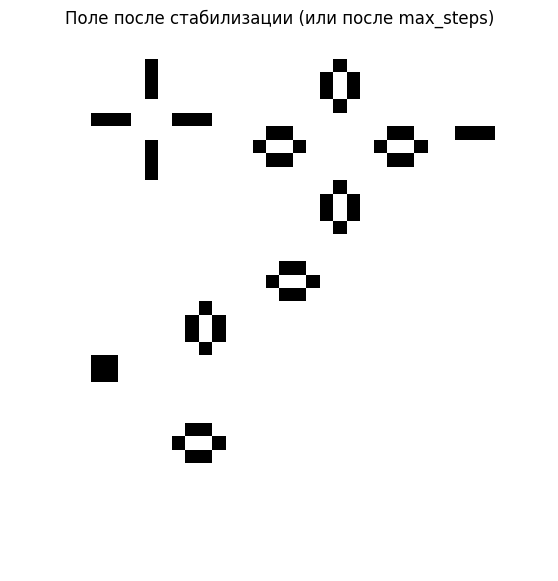

,pattern,count
1,beehive,7
0,blinker,5
2,block,1


Всего изолированных объектов: 13
Неизвестных объектов: 0


In [ ]:
pattern_counts, components = classify_board_objects(sample_final_board, pattern_library)

plt.figure(figsize=(7, 7))
plt.imshow(sample_final_board, interpolation="nearest")
plt.title("Поле после стабилизации (или после max_steps)")
plt.axis("off")
plt.show()

pattern_df = pd.DataFrame({
    "pattern": list(pattern_counts.keys()),
    "count": list(pattern_counts.values())
}).sort_values("count", ascending=False)

display(pattern_df)

print("Всего изолированных объектов:", sum(pattern_counts.values()))
print("Неизвестных объектов:", pattern_counts.get("unknown", 0))


## Цель работы

Изучение принципов функционирования клеточных автоматов и приобретение навыков их программной реализации как дискретных вычислительных моделей.
В работе исследуются:
- элементарный одномерный клеточный автомат;
- двумерный клеточный автомат «Жизнь» Конвея;
- зависимость времени стабилизации двумерного автомата от начальной плотности заполнения;
- возникающие паттерны: **устойчивые**, **периодические** и **движущиеся**.


##Диаграмма классов разработанных моделей клеточных автоматов

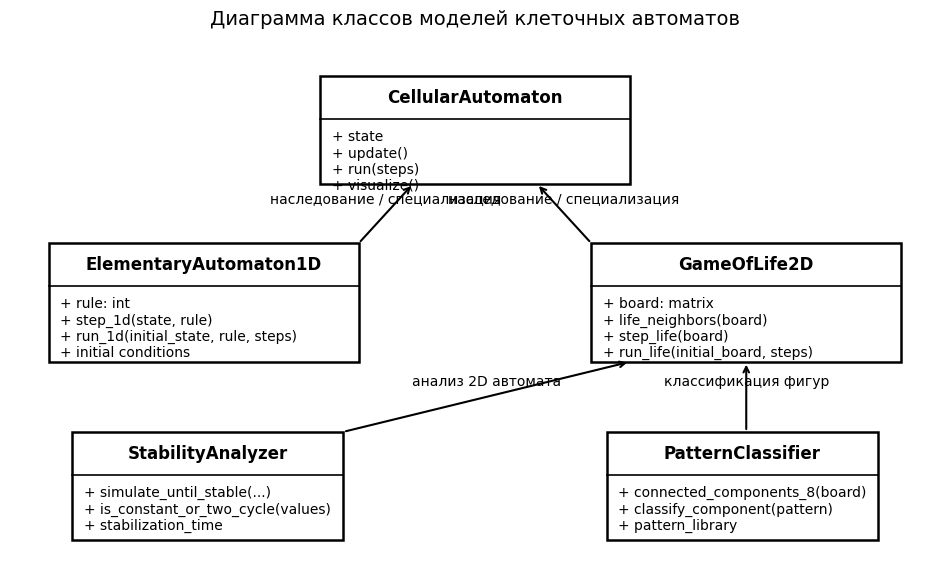

##Визуализации эволюций исследуемых автоматов с указанием выявленных паттернов

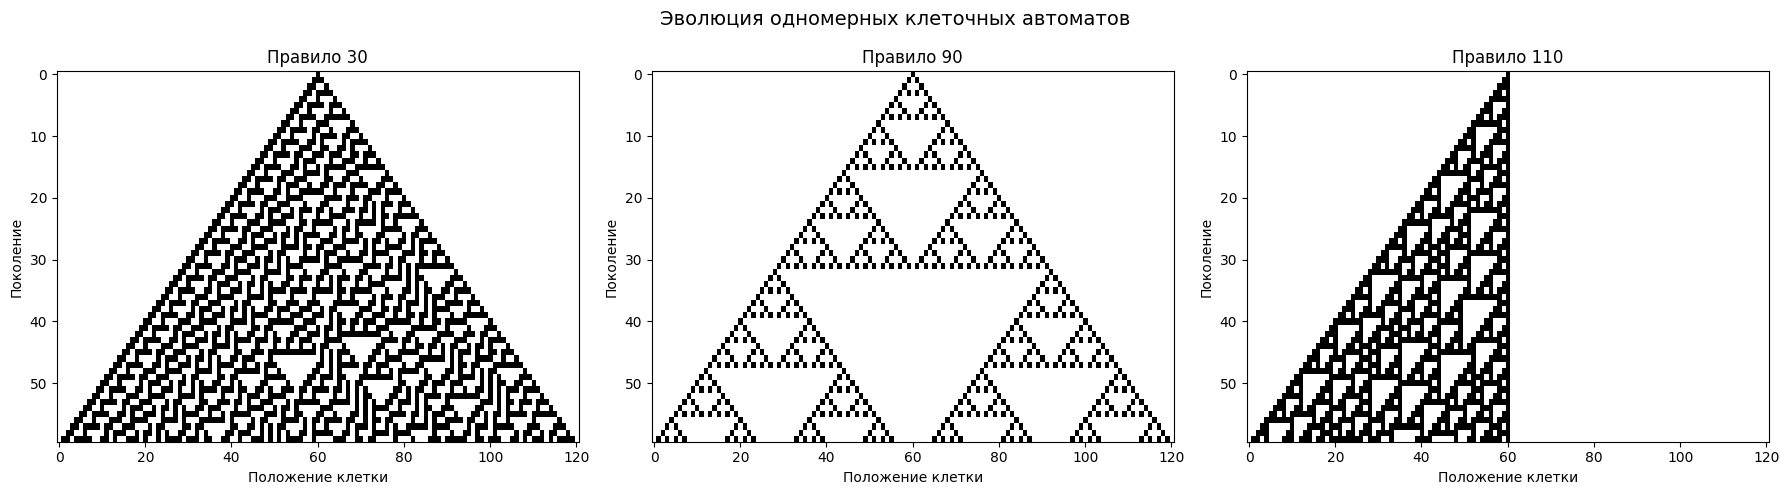


**Краткая интерпретация:**
- **Правило 30** — сложное, визуально хаотичное поведение;
- **Правило 90** — регулярный фрактальный узор;
- **Правило 110** — сложная структура между порядком и хаосом.


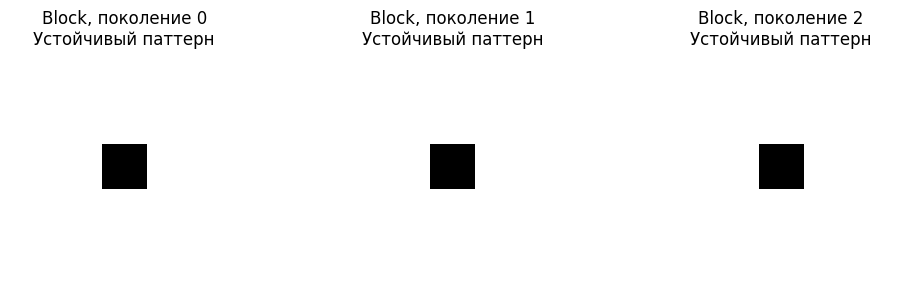

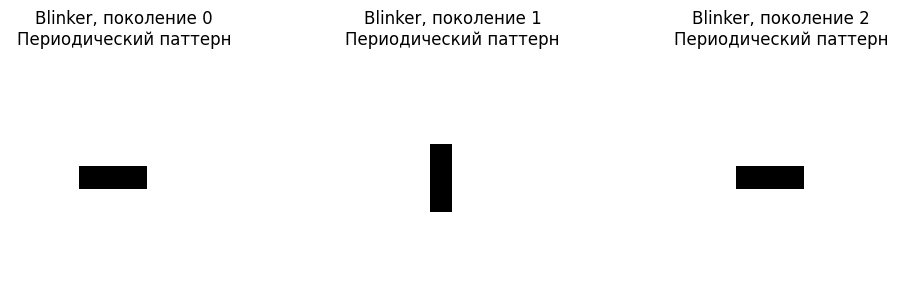

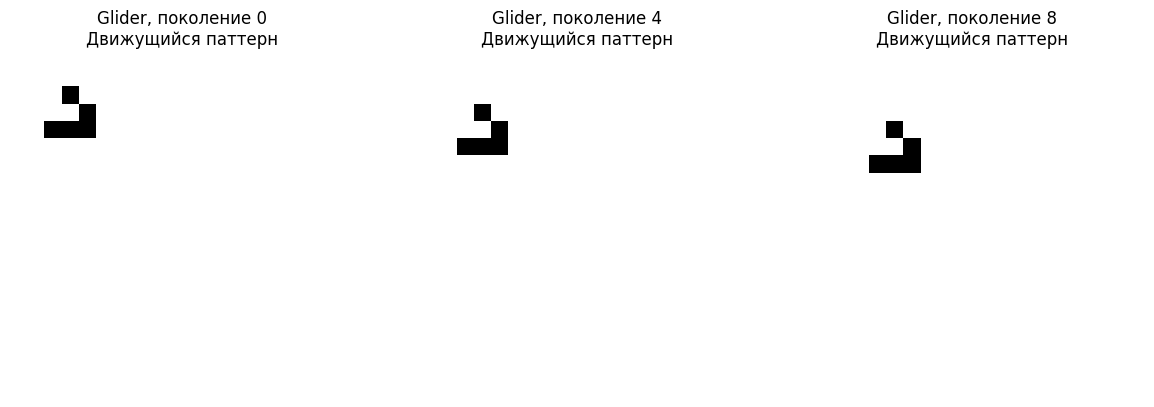

##Таблица с результатами замеров времени стабилизации для разных плотностей заполнения

,p,avg_stabilization_time,std_stabilization_time,stabilized_runs,total_runs
0,0.1,97.75,91.21,8,10
1,0.2,195.80,65.47,5,10
2,0.3,167.00,70.06,3,10
3,0.4,183.00,39.81,4,10
4,0.5,242.00,48.60,4,10
5,0.6,193.83,57.90,6,10
6,0.7,89.29,47.58,7,10
7,0.8,42.80,77.86,10,10
8,0.9,11.70,0.46,10,10


##График зависимости времени стабилизации от плотности заполнения

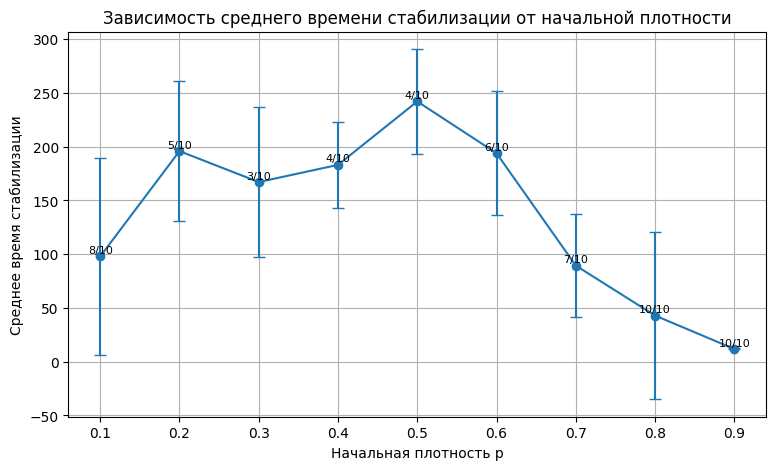

##Анализ результатов


По результатам экспериментов максимальное среднее время стабилизации наблюдается при **p = 0.5**
(**среднее время ≈ 242.00**). Это соответствует наиболее выраженной
**хаотической фазе**, когда взаимодействий между клетками достаточно много, но система ещё не переходит
к быстрому вымиранию или к простому устойчивому режиму.

Минимальное среднее время стабилизации наблюдается при **p = 0.9**
(**среднее время ≈ 11.70**). Это означает, что при такой плотности
система быстрее всего приходит к простому состоянию: либо быстро **вымирает**, либо быстро
**кристаллизуется** в набор устойчивых и периодических фигур.

Дополнительно по числу успешных стабилизаций:
- больше всего стабилизировавшихся запусков: **p = 0.8**, 10/10;
- меньше всего стабилизировавшихся запусков: **p = 0.3**, 3/10.

### Общий вывод
Зависимость времени стабилизации от плотности заполнения является **немонотонной**:
- при слишком малой плотности клеткам часто не хватает соседей, поэтому активность быстро затухает;
- при слишком большой плотности возникает перенаселение, что тоже ускоряет разрушение начальной конфигурации;
- наиболее длительная и сложная динамика обычно возникает при **средних значениях плотности**.


In [ ]:
#ОТЧЁТ

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


try:
    run_1d
    single_cell_initial
    random_initial
    step_life
    run_life
    random_board
    results_df
except NameError:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from collections import deque, Counter

    def rule_to_outputs(rule: int) -> np.ndarray:
        return np.array([(rule >> i) & 1 for i in range(8)], dtype=np.uint8)

    def step_1d(state: np.ndarray, rule: int) -> np.ndarray:
        outputs = rule_to_outputs(rule)
        padded = np.pad(state, (1, 1), mode="constant", constant_values=0)
        left = padded[:-2]
        center = padded[1:-1]
        right = padded[2:]
        idx = (left << 2) | (center << 1) | right
        return outputs[idx]

    def run_1d(initial_state: np.ndarray, rule: int, steps: int) -> np.ndarray:
        state = initial_state.copy().astype(np.uint8)
        history = [state.copy()]
        for _ in range(steps - 1):
            state = step_1d(state, rule)
            history.append(state.copy())
        return np.array(history)

    def single_cell_initial(width: int) -> np.ndarray:
        state = np.zeros(width, dtype=np.uint8)
        state[width // 2] = 1
        return state

    def random_initial(width: int, p: float = 0.5, seed: int = None) -> np.ndarray:
        rng = np.random.default_rng(seed)
        return (rng.random(width) < p).astype(np.uint8)

    def random_board(rows: int, cols: int, p: float = 0.3, seed: int = None) -> np.ndarray:
        rng = np.random.default_rng(seed)
        return (rng.random((rows, cols)) < p).astype(np.uint8)

    def life_neighbors(board: np.ndarray) -> np.ndarray:
        padded = np.pad(board, 1, mode="constant", constant_values=0)
        neighbors = (
            padded[:-2, :-2] + padded[:-2, 1:-1] + padded[:-2, 2:] +
            padded[1:-1, :-2]                      + padded[1:-1, 2:] +
            padded[2:, :-2]  + padded[2:, 1:-1]  + padded[2:, 2:]
        )
        return neighbors

    def step_life(board: np.ndarray) -> np.ndarray:
        n = life_neighbors(board)
        next_board = (
            ((board == 1) & ((n == 2) | (n == 3))) |
            ((board == 0) & (n == 3))
        )
        return next_board.astype(np.uint8)

    def run_life(initial_board: np.ndarray, steps: int):
        board = initial_board.copy().astype(np.uint8)
        history = [board.copy()]
        for _ in range(steps):
            board = step_life(board)
            history.append(board.copy())
        return history

    def is_constant_or_two_cycle(values) -> bool:
        values = list(values)
        if len(set(values)) == 1:
            return True
        if len(set(values)) > 2:
            return False
        a = values[0]
        b = values[1]
        return all(values[i] == (a if i % 2 == 0 else b) for i in range(len(values)))

    def simulate_until_stable(initial_board: np.ndarray, max_steps: int = 300, window: int = 10):
        board = initial_board.copy().astype(np.uint8)
        counts = [int(board.sum())]
        for step in range(1, max_steps + 1):
            board = step_life(board)
            counts.append(int(board.sum()))
            if len(counts) >= window and is_constant_or_two_cycle(counts[-window:]):
                return step
        return np.nan

    p_values = np.linspace(0.1, 0.9, 9)
    runs_per_p = 10
    rows, cols = 40, 40
    rng = np.random.default_rng(123)

    rows_list = []
    for p in p_values:
        times = []
        for _ in range(runs_per_p):
            board = (rng.random((rows, cols)) < p).astype(np.uint8)
            t = simulate_until_stable(board, max_steps=300, window=10)
            times.append(t)

        arr = np.array(times, dtype=float)
        rows_list.append({
            "p": p,
            "avg_stabilization_time": np.nanmean(arr) if np.isfinite(arr).any() else np.nan,
            "std_stabilization_time": np.nanstd(arr) if np.isfinite(arr).any() else np.nan,
            "stabilized_runs": int(np.isfinite(arr).sum()),
            "total_runs": runs_per_p
        })

    results_df = pd.DataFrame(rows_list)

display(Markdown("""
## Цель работы

Изучение принципов функционирования клеточных автоматов и приобретение навыков их программной реализации как дискретных вычислительных моделей.
В работе исследуются:
- элементарный одномерный клеточный автомат;
- двумерный клеточный автомат «Жизнь» Конвея;
- зависимость времени стабилизации двумерного автомата от начальной плотности заполнения;
- возникающие паттерны: **устойчивые**, **периодические** и **движущиеся**.
"""))

# Диаграмма классов
display(Markdown("##Диаграмма классов разработанных моделей клеточных автоматов"))

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis("off")

def draw_box(x, y, w, h, title, lines):
    rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=1.8)
    ax.add_patch(rect)
    ax.plot([x, x+w], [y+h-0.8, y+h-0.8], color='black', linewidth=1.2)
    ax.text(x + w/2, y + h - 0.4, title, ha='center', va='center', fontsize=12, fontweight='bold')
    text = "\n".join(lines)
    ax.text(x + 0.15, y + h - 1.0, text, ha='left', va='top', fontsize=10)

def arrow(x1, y1, x2, y2, text=None):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", linewidth=1.5))
    if text:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.2, text, fontsize=10, ha='center')

draw_box(4.0, 7.2, 4.0, 2.0, "CellularAutomaton",
         ["+ state", "+ update()", "+ run(steps)", "+ visualize()"])

draw_box(0.5, 3.9, 4.0, 2.2, "ElementaryAutomaton1D",
         ["+ rule: int", "+ step_1d(state, rule)",
          "+ run_1d(initial_state, rule, steps)",
          "+ initial conditions"])

draw_box(7.5, 3.9, 4.0, 2.2, "GameOfLife2D",
         ["+ board: matrix", "+ life_neighbors(board)",
          "+ step_life(board)", "+ run_life(initial_board, steps)"])

draw_box(0.8, 0.6, 3.5, 2.0, "StabilityAnalyzer",
         ["+ simulate_until_stable(...)",
          "+ is_constant_or_two_cycle(values)",
          "+ stabilization_time"])

draw_box(7.7, 0.6, 3.5, 2.0, "PatternClassifier",
         ["+ connected_components_8(board)",
          "+ classify_component(pattern)",
          "+ pattern_library"])

arrow(4.5, 6.1, 5.2, 7.2, "наследование / специализация")
arrow(7.5, 6.1, 6.8, 7.2, "наследование / специализация")
arrow(4.3, 2.6, 8.0, 3.9, "анализ 2D автомата")
arrow(9.5, 2.6, 9.5, 3.9, "классификация фигур")

plt.title("Диаграмма классов моделей клеточных автоматов", fontsize=14)
plt.show()

# Визуализации эволюций с паттернами
display(Markdown("##Визуализации эволюций исследуемых автоматов с указанием выявленных паттернов"))

#Одномерные автоматы
width = 121
steps = 60
rules = [30, 90, 110]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, rule in zip(axes, rules):
    hist = run_1d(single_cell_initial(width), rule, steps)
    ax.imshow(hist, interpolation="nearest", aspect="auto", cmap="binary")
    ax.set_title(f"Правило {rule}")
    ax.set_xlabel("Положение клетки")
    ax.set_ylabel("Поколение")
plt.suptitle("Эволюция одномерных клеточных автоматов", fontsize=14)
plt.tight_layout()
plt.show()

display(Markdown("""
**Краткая интерпретация:**
- **Правило 30** — сложное, визуально хаотичное поведение;
- **Правило 90** — регулярный фрактальный узор;
- **Правило 110** — сложная структура между порядком и хаосом.
"""))

#Устойчивый паттерн: block
block = np.array([[1, 1],
                  [1, 1]], dtype=np.uint8)

board_block = np.zeros((10, 10), dtype=np.uint8)
board_block[4:6, 4:6] = block
hist_block = [board_block.copy()]
for _ in range(2):
    hist_block.append(step_life(hist_block[-1]))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(hist_block[i], cmap="binary", interpolation="nearest")
    ax.set_title(f"Block, поколение {i}\nУстойчивый паттерн")
    ax.axis("off")
plt.tight_layout()
plt.show()

#Периодический паттерн: blinker
blinker = np.array([[1, 1, 1]], dtype=np.uint8)

board_blinker = np.zeros((10, 10), dtype=np.uint8)
board_blinker[5, 3:6] = 1
hist_blinker = [board_blinker.copy()]
for _ in range(2):
    hist_blinker.append(step_life(hist_blinker[-1]))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(hist_blinker[i], cmap="binary", interpolation="nearest")
    ax.set_title(f"Blinker, поколение {i}\nПериодический паттерн")
    ax.axis("off")
plt.tight_layout()
plt.show()

#Движущийся паттерн: glider
glider = np.array([[0, 1, 0],
                   [0, 0, 1],
                   [1, 1, 1]], dtype=np.uint8)

board_glider = np.zeros((20, 20), dtype=np.uint8)
board_glider[2:5, 2:5] = glider
hist_glider = [board_glider.copy()]
for _ in range(8):
    hist_glider.append(step_life(hist_glider[-1]))

gens = [0, 4, 8]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, g in zip(axes, gens):
    ax.imshow(hist_glider[g], cmap="binary", interpolation="nearest")
    ax.set_title(f"Glider, поколение {g}\nДвижущийся паттерн")
    ax.axis("off")
plt.tight_layout()
plt.show()

#Таблица с результатами
display(Markdown("##Таблица с результатами замеров времени стабилизации для разных плотностей заполнения"))

table_df = results_df.copy()
table_df["p"] = table_df["p"].round(2)
table_df["avg_stabilization_time"] = table_df["avg_stabilization_time"].round(2)
table_df["std_stabilization_time"] = table_df["std_stabilization_time"].round(2)
display(table_df)

#График зависимости
display(Markdown("##График зависимости времени стабилизации от плотности заполнения"))

plt.figure(figsize=(9, 5))
plt.errorbar(
    results_df["p"],
    results_df["avg_stabilization_time"],
    yerr=results_df["std_stabilization_time"],
    marker="o",
    capsize=4
)
plt.title("Зависимость среднего времени стабилизации от начальной плотности")
plt.xlabel("Начальная плотность p")
plt.ylabel("Среднее время стабилизации")
plt.grid(True)

for _, row in results_df.iterrows():
    if pd.notna(row["avg_stabilization_time"]):
        plt.text(
            row["p"],
            row["avg_stabilization_time"] + 3,
            f'{int(row["stabilized_runs"])}/{int(row["total_runs"])}',
            ha="center",
            fontsize=8
        )
plt.show()

#Анализ результатов
display(Markdown("##Анализ результатов"))

valid_df = results_df.dropna(subset=["avg_stabilization_time"]).copy()

if len(valid_df) > 0:
    max_row = valid_df.loc[valid_df["avg_stabilization_time"].idxmax()]
    min_row = valid_df.loc[valid_df["avg_stabilization_time"].idxmin()]
    best_stab = valid_df.loc[valid_df["stabilized_runs"].idxmax()]
    worst_stab = valid_df.loc[valid_df["stabilized_runs"].idxmin()]

    analysis_text = f"""
По результатам экспериментов максимальное среднее время стабилизации наблюдается при **p = {max_row['p']:.1f}**
(**среднее время ≈ {max_row['avg_stabilization_time']:.2f}**). Это соответствует наиболее выраженной
**хаотической фазе**, когда взаимодействий между клетками достаточно много, но система ещё не переходит
к быстрому вымиранию или к простому устойчивому режиму.

Минимальное среднее время стабилизации наблюдается при **p = {min_row['p']:.1f}**
(**среднее время ≈ {min_row['avg_stabilization_time']:.2f}**). Это означает, что при такой плотности
система быстрее всего приходит к простому состоянию: либо быстро **вымирает**, либо быстро
**кристаллизуется** в набор устойчивых и периодических фигур.

Дополнительно по числу успешных стабилизаций:
- больше всего стабилизировавшихся запусков: **p = {best_stab['p']:.1f}**, {int(best_stab['stabilized_runs'])}/{int(best_stab['total_runs'])};
- меньше всего стабилизировавшихся запусков: **p = {worst_stab['p']:.1f}**, {int(worst_stab['stabilized_runs'])}/{int(worst_stab['total_runs'])}.

### Общий вывод
Зависимость времени стабилизации от плотности заполнения является **немонотонной**:
- при слишком малой плотности клеткам часто не хватает соседей, поэтому активность быстро затухает;
- при слишком большой плотности возникает перенаселение, что тоже ускоряет разрушение начальной конфигурации;
- наиболее длительная и сложная динамика обычно возникает при **средних значениях плотности**.
"""
    display(Markdown(analysis_text))
else:
    display(Markdown("Недостаточно данных для автоматического анализа результатов."))